# Portfolio Performance Dashboard
This notebook builds a portfolio performance analysis tool using real market data 
from Yahoo Finance. The user inputs any combination of Stocks and ETFs tickers along 
with a custom date range, and the tool automatically calculates four institutional-grade 
metrics:
1. Total Return
2. Annualized Volatility
3. Sharpe Ratio
4. Max Drawdown
— for each asset in the portfolio.

For benchmarking results to a relevant index like S&P500, add SPY or VOO as one of your tickers to evaluate whether individual holdings justified their risk relative to simply holding an index fund. Three visualizations are generated: 
1. Cumulative Returns Chart
2. Drawdown Chart
3. Four-panel Summary Dashboard

Built with yfinance, pandas, numpy, and matplotlib.


In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

1. `import yfinance as yf` - Imports the yfinance library with the alias 'yf'. This library allows you to download financial market data from Yahoo Finance.

2. `import pandas as pd` - Imports the pandas library with the alias 'pd'. Pandas provides data structures and functions for data manipulation and analysis.

3. `import numpy as np` - Imports the numpy library with the alias 'np'. NumPy is used for numerical computing with Python, providing support for arrays, matrices, and mathematical functions.

4. `import matplotlib.pyplot as plt` - Imports the pyplot module from the matplotlib library with the alias 'plt'. This module provides functions for creating visualizations and plots.

In [2]:
tickers_input = input("Enter tickers separated by commas: ")
tickers = [t.strip().upper() for t in tickers_input.split(',')]
start_date = input("Enter start date (YYYY-MM-DD): ")
end_date = input("Enter end date (YYYY-MM-DD): ")
print(f"Analyzing from {start_date} to {end_date}")
print("Your portfolio:", tickers)

Enter tickers separated by commas:  aapl,meta,jpm,rklb,sofi,qqq,spy
Enter start date (YYYY-MM-DD):  2020-01-01
Enter end date (YYYY-MM-DD):  2026-02-28


Analyzing from 2020-01-01 to 2026-02-28
Your portfolio: ['AAPL', 'META', 'JPM', 'RKLB', 'SOFI', 'QQQ', 'SPY']


1. `tickers_input = input("Enter tickers separated by commas: ")` - Prompts the user to enter stock ticker symbols separated by commas and stores the input as a string.

2. `tickers = [t.strip().upper() for t in tickers_input.split(',')]` - Processes the input string by:
   - Splitting it at each comma using `split(',')`
   - Using a list comprehension to process each ticker symbol
   - Removing whitespace with `strip()`
   - Converting to uppercase with `upper()`
   - Creating a list of cleaned ticker symbols

3. `start_date = input("Enter start date (YYYY-MM-DD): ")` - Prompts for and stores the analysis start date.

4. `end_date = input("Enter end date (YYYY-MM-DD): ")` - Prompts for and stores the analysis end date.

5. The last two `print()` statements confirm the inputs by displaying the date range and list of tickers.

In [3]:
prices = yf.download(tickers, start=start_date, end=end_date, auto_adjust=False)['Adj Close']
returns = prices.pct_change().dropna()

[*********************100%***********************]  7 of 7 completed


1. `prices = yf.download(tickers, start=start_date, end=end_date, auto_adjust=False)['Adj Close']`
   - Uses the Yahoo Finance API (via the `yf` module) to download historical stock data
   - Downloads data for all tickers in the `tickers` list
   - Retrieves data from `start_date` to `end_date` (dates provided by user input)
   - Sets `auto_adjust=False` to get unadjusted prices
   - Extracts only the 'Adj Close' (adjusted closing price) column from the downloaded data

2. `returns = prices.pct_change().dropna()`
   - Calculates the percentage change between consecutive days using `pct_change()`
   - This effectively converts price data into daily returns
   - Uses `dropna()` to remove any rows with missing values (typically the first row since there's no previous day to calculate returns from)

The resulting `returns` DataFrame contains the daily percentage returns for all requested stocks.

In [4]:
returns.head()

Ticker,AAPL,JPM,META,QQQ,RKLB,SOFI,SPY
Date,,,,,,,
2021-01-05,0.012363,0.005441,0.007548,0.008244,0.005146,-0.004098,0.006887
2021-01-06,-0.033661,0.046956,-0.028269,-0.013852,0.002608,-0.002469,0.005979
2021-01-07,0.034123,0.032839,0.020622,0.024192,0.002890,0.579208,0.014858
2021-01-08,0.008631,0.001104,-0.004354,0.012858,0.000961,-0.020899,0.005697
2021-01-11,-0.023249,0.014924,-0.040102,-0.014450,-0.001919,0.013340,-0.006740


The selected code `returns.head()` displays the first few rows of a DataFrame called `returns`. 

This method:
- Shows the first 5 rows by default (though you can specify a different number as an argument)
- Is commonly used to quickly inspect the structure and content of a DataFrame
- Helps verify that data has been loaded or transformed correctly

This is a standard pandas function used for data exploration to get a quick preview of your data.

In [5]:
total_return = (1 + returns).prod() - 1
print(total_return.round(4))

Ticker
AAPL    1.0991
JPM     1.7287
META    1.4270
QQQ     1.0232
RKLB    5.7087
SOFI    0.4557
SPY     0.9927
dtype: float64


1. `(1 + returns).prod()` - This adds 1 to each value in the `returns` series (converting each return to a growth factor), then uses the `prod()` method to multiply all these values together, giving the cumulative growth factor.

2. `(1 + returns).prod() - 1` - This subtracts 1 from the cumulative growth factor to convert it back to a return value, representing the total percentage return across all periods.

3. `total_return = ...` - The result is stored in a variable called `total_return`.

4. `total_return.round(4)` - This rounds the total return value to 4 decimal places.

5. `print(total_return.round(4))` - This prints the rounded total return value to the console.

These numbers mean for every $1 you invested, here's how much you made on top of it.

Example: 3.5244 means: a 10,000 investment became 35,244

In percentage terms, just multiply by 100:

Example: 2.8723 means: 287.23% return

In [6]:
volatility = returns.std() * np.sqrt(252)
print(volatility.round(4))

Ticker
AAPL    0.2786
JPM     0.2442
META    0.4330
QQQ     0.2250
RKLB    0.7709
SOFI    0.7333
SPY     0.1697
dtype: float64


1. `returns.std()` - Calculates the standard deviation of the returns data, which measures how much the returns fluctuate around their mean.

2. `* np.sqrt(252)` - Multiplies the standard deviation by the square root of 252. This is a common finance technique to annualize daily volatility, assuming there are 252 trading days in a year.

3. `volatility = ...` - Assigns the calculated annualized volatility to a variable named 'volatility'.

4. `print(volatility.round(4))` - Prints the volatility values rounded to 4 decimal places, making the output more readable.

This code is typically used in financial analysis to measure the risk or volatility of investments on an annual basis.

np.sqrt(252) — scales it from daily to annual. There are 252 trading days in a year, and this is the mathematically correct way to annualize volatility (you square root time in finance, not multiply directly

How to read the output: a volatility of 0.25 means the asset moves roughly ±25% per year. Higher number = wilder ride.

In [7]:
RISK_FREE = 0.042 #as of March 2026 based on 10Y US Treasury
excess_returns = returns.mean() * 252 - RISK_FREE
sharpe = excess_returns / volatility
print(sharpe.round(4))

Ticker
AAPL    0.5067
JPM     0.7514
META    0.5209
QQQ     0.5361
RKLB    0.7999
SOFI    0.3923
SPY     0.6291
dtype: float64


1. `RISK_FREE = 0.042` - Defines the risk-free rate as 4.2%.

2. `excess_returns = returns.mean() * 252 - RISK_FREE` - Calculates the excess returns by:
   - Taking the mean of daily returns
   - Annualizing it by multiplying by 252 (typical number of trading days in a year)
   - Subtracting the risk-free rate to get the excess return

3. `sharpe = excess_returns / volatility` - Computes the Sharpe ratio by dividing the excess returns by the volatility (which appears to be defined elsewhere in the code).

4. `print(sharpe.round(4))` - Prints the Sharpe ratio rounded to 4 decimal places.

In [8]:
cumulative = (1 + returns).cumprod()
rolling_max = cumulative.cummax()

1. `cumulative = (1 + returns).cumprod()` - This line calculates the cumulative product of (1 + returns). In finance, this represents the cumulative return or the total value of an investment over time. Starting with 1 and multiplying by (1 + each period's return) gives you the growth of $1 invested at the beginning.

2. `rolling_max = cumulative.cummax()` - This line calculates the running maximum of the cumulative returns. For each point in time, it records the highest value that the cumulative return has reached up to that point. This is often used to identify drawdowns or to track the historical high watermark of an investment.

In [9]:
cumulative

Ticker,AAPL,JPM,META,QQQ,RKLB,SOFI,SPY
Date,,,,,,,
2021-01-05,1.012363,1.005441,1.007548,1.008244,1.005146,0.995902,1.006887
2021-01-06,0.978286,1.052652,0.979066,0.994278,1.007767,0.993443,1.012907
2021-01-07,1.011668,1.087221,0.999257,1.018331,1.010680,1.568852,1.027956
2021-01-08,1.020400,1.088421,0.994906,1.031425,1.011650,1.536066,1.033813
2021-01-11,0.996677,1.104665,0.955009,1.016521,1.009709,1.556557,1.026845
...,...,...,...,...,...,...,...
2026-02-23,2.114944,2.704814,2.386040,2.003611,6.816505,1.493443,1.982212
2026-02-24,2.162300,2.701452,2.393715,2.025132,6.793204,1.529508,1.996620
2026-02-25,2.178906,2.755972,2.447596,2.054483,6.815534,1.581148,2.013468


In [10]:
rolling_max

Ticker,AAPL,JPM,META,QQQ,RKLB,SOFI,SPY
Date,,,,,,,
2021-01-05,1.012363,1.005441,1.007548,1.008244,1.005146,0.995902,1.006887
2021-01-06,1.012363,1.052652,1.007548,1.008244,1.007767,0.995902,1.012907
2021-01-07,1.012363,1.087221,1.007548,1.018331,1.010680,1.568852,1.027956
2021-01-08,1.020400,1.088421,1.007548,1.031425,1.011650,1.568852,1.033813
2021-01-11,1.020400,1.104665,1.007548,1.031425,1.011650,1.568852,1.033813
...,...,...,...,...,...,...,...
2026-02-23,2.271809,3.040474,2.953574,2.115357,9.349515,2.640164,2.020265
2026-02-24,2.271809,3.040474,2.953574,2.115357,9.349515,2.640164,2.020265
2026-02-25,2.271809,3.040474,2.953574,2.115357,9.349515,2.640164,2.020265


In [11]:
drawdown = (cumulative - rolling_max) / rolling_max
max_drawdown = drawdown.min()
print(max_drawdown.round(4))

Ticker
AAPL   -0.3336
JPM    -0.3877
META   -0.7674
QQQ    -0.3512
RKLB   -0.8296
SOFI   -0.8332
SPY    -0.2450
dtype: float64


1. `drawdown = (cumulative - rolling_max) / rolling_max` - This calculates the drawdown at each point by:
   - Taking the difference between the cumulative returns and the rolling maximum
   - Dividing by the rolling maximum to express it as a percentage/proportion

2. `max_drawdown = drawdown.min()` - This finds the minimum value in the drawdown series, which represents the maximum drawdown (the worst decline from a peak)

3. `print(max_drawdown.round(4))` - This prints the maximum drawdown value rounded to 4 decimal places

Maximum drawdown is an important risk metric in finance that measures the largest percentage drop from a peak to a subsequent trough.

In [12]:
summary = pd.DataFrame({
    'Total Return':   total_return.round(4),
    'Volatility':     volatility.round(4),
    'Sharpe Ratio':   sharpe.round(4),
    'Max Drawdown':   max_drawdown.round(4)
})
print(summary)

        Total Return  Volatility  Sharpe Ratio  Max Drawdown
Ticker                                                      
AAPL          1.0991      0.2786        0.5067       -0.3336
JPM           1.7287      0.2442        0.7514       -0.3877
META          1.4270      0.4330        0.5209       -0.7674
QQQ           1.0232      0.2250        0.5361       -0.3512
RKLB          5.7087      0.7709        0.7999       -0.8296
SOFI          0.4557      0.7333        0.3923       -0.8332
SPY           0.9927      0.1697        0.6291       -0.2450


1. `summary = pd.DataFrame({...})` - Creates a new pandas DataFrame with specific financial metrics as columns.

2. The DataFrame contains four columns of performance metrics:
   - `'Total Return'`: The overall investment return, rounded to 4 decimal places
   - `'Volatility'`: A measure of price fluctuation/risk, rounded to 4 decimal places
   - `'Sharpe Ratio'`: A measure of risk-adjusted return, rounded to 4 decimal places
   - `'Max Drawdown'`: The largest percentage drop from peak to trough, rounded to 4 decimal places

3. `print(summary)` - Displays the summary DataFrame in the notebook output.

This code is creating a clean, formatted table of key performance metrics that would typically be used to evaluate and compare investment strategies.

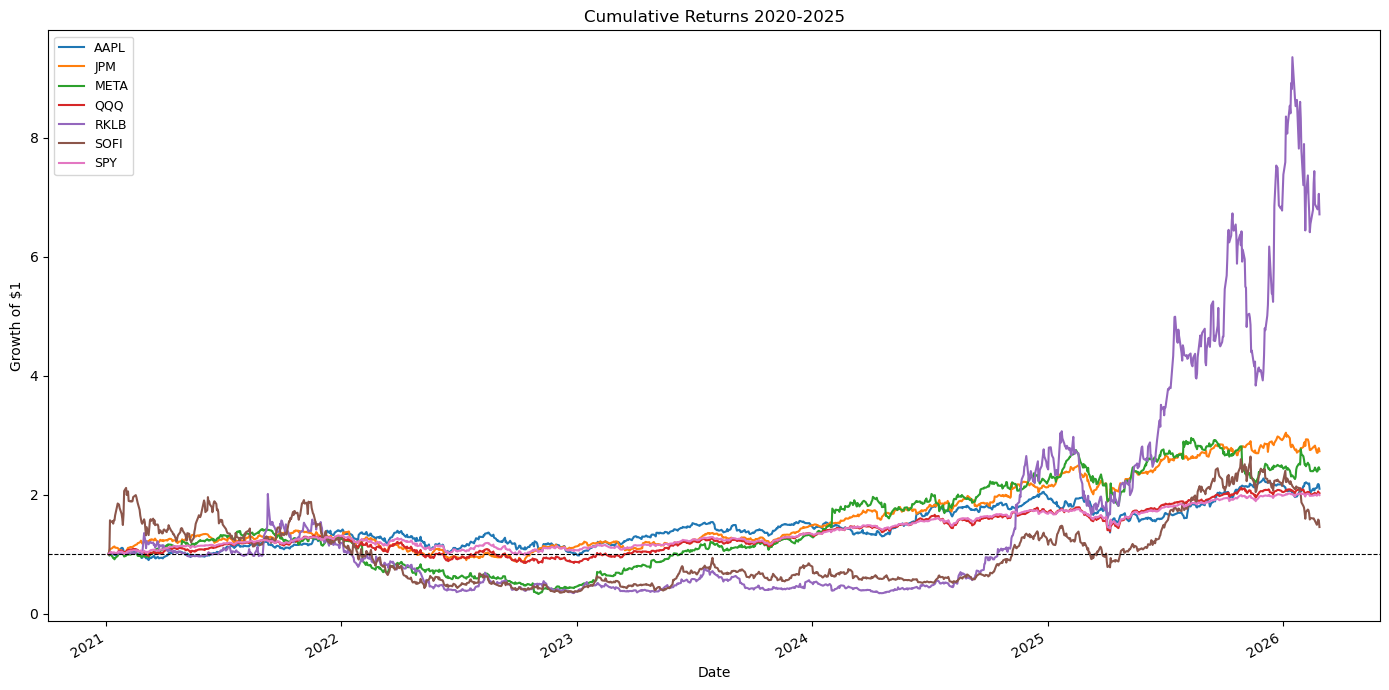

In [13]:
fig, ax = plt.subplots(figsize=(14, 7))
cumulative.plot(ax=ax)
ax.set_title('Cumulative Returns 2020-2025')
ax.set_ylabel('Growth of $1')
ax.set_xlabel('Date')
ax.axhline(y=1, color='black', linestyle='--', linewidth=0.8)
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

1. `fig, ax = plt.subplots(figsize=(14, 7))` - Creates a new figure with a single subplot, setting the figure size to 14 inches wide by 7 inches tall.

2. `cumulative.plot(ax=ax)` - Plots the cumulative returns data on the created axes.

3. `ax.set_title('Cumulative Returns 2020-2025')` - Sets the title of the plot.

4. `ax.set_ylabel('Growth of $1')` - Sets the y-axis label to indicate the growth metric.

5. `ax.set_xlabel('Date')` - Sets the x-axis label.

6. `ax.axhline(y=1, color='black', linestyle='--', linewidth=0.8)` - Adds a horizontal reference line at y=1 (the starting point for returns), styled as a thin black dashed line.

7. `ax.legend(loc='upper left', fontsize=9)` - Positions the legend in the upper left corner with a font size of 9.

8. `plt.tight_layout()` - Adjusts the padding between and around subplots for optimal display.

9. `plt.show()` - Displays the figure.

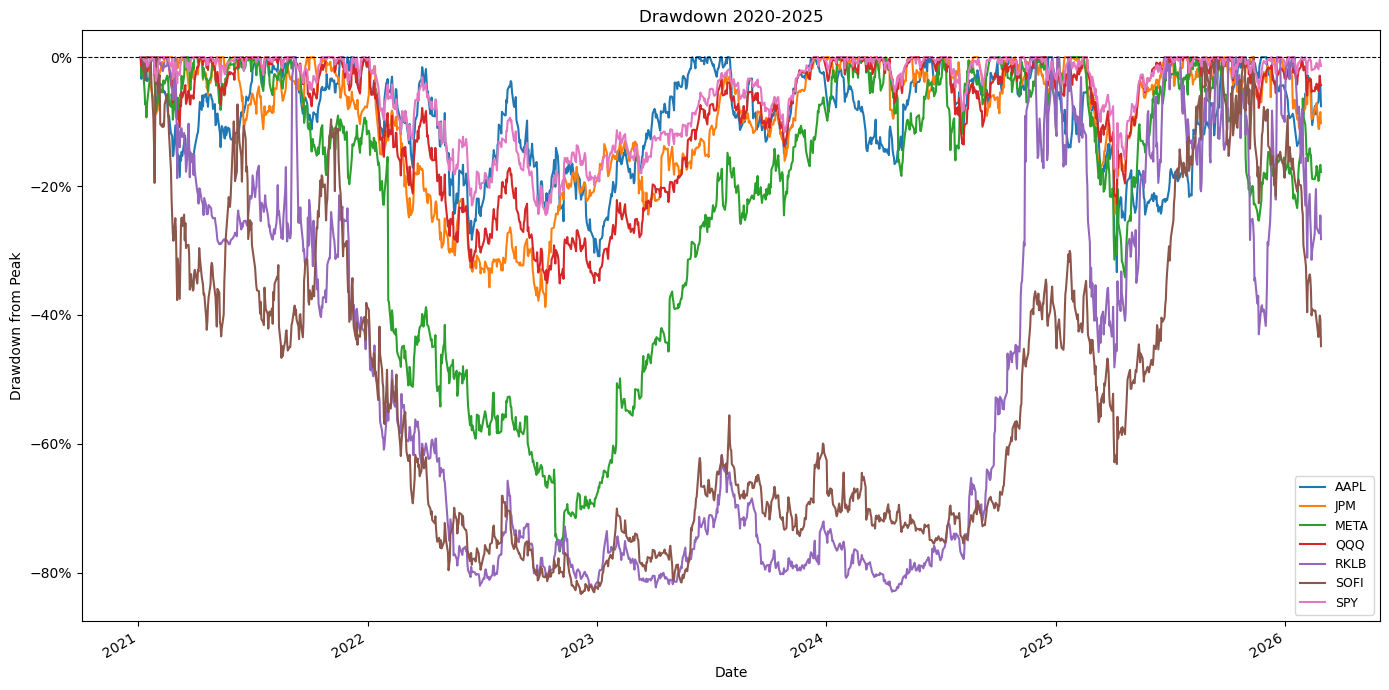

In [14]:
import matplotlib.ticker as mtick
fig, ax = plt.subplots(figsize=(14, 7))
drawdown.plot(ax=ax)
ax.set_title('Drawdown 2020-2025')
ax.set_ylabel('Drawdown from Peak')
ax.set_xlabel('Date')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()


1. `import matplotlib.ticker as mtick` - Imports the ticker module from matplotlib, which provides tools for customizing axis tick labels.

2. `fig, ax = plt.subplots(figsize=(14, 7))` - Creates a figure and a single subplot with dimensions 14×7 inches.

3. `drawdown.plot(ax=ax)` - Plots the drawdown data on the created axis.

4. `ax.set_title('Drawdown 2020-2025')` - Sets the title of the plot.

5. `ax.set_ylabel('Drawdown from Peak')` - Sets the y-axis label.

6. `ax.set_xlabel('Date')` - Sets the x-axis label.

7. `ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))` - Formats the y-axis values as percentages, where 1.0 represents 100%.

8. `ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8)` - Adds a horizontal dashed black line at y=0.

9. `ax.legend(loc='lower right', fontsize=9)` - Places the legend in the lower right corner with font size 9.

10. `plt.tight_layout()` - Adjusts the plot to ensure all elements fit without overlapping.

11. `plt.show()` - Displays the final plot.

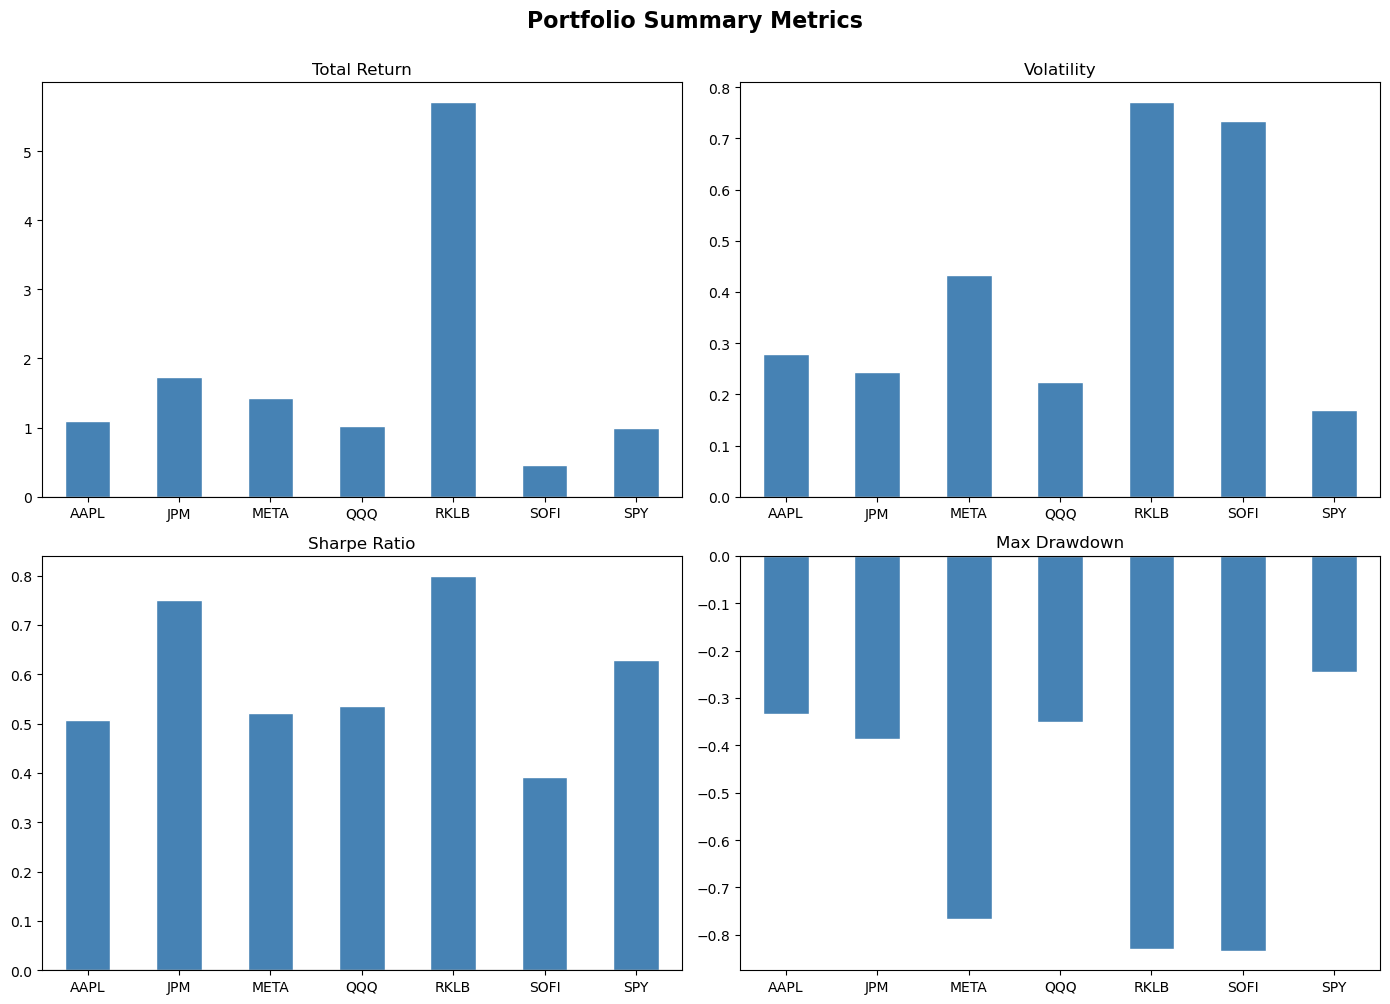

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics = ['Total Return', 'Volatility', 'Sharpe Ratio', 'Max Drawdown']

for i, metric in enumerate(metrics):
    ax = axes[i // 2, i % 2]
    summary[metric].plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(metric)
    ax.set_xlabel('')
    ax.tick_params(axis='x',rotation=360)
    ax.axhline(y=0, color='black', linewidth=0.8)

plt.suptitle('Portfolio Summary Metrics', fontsize=16, fontweight='bold', y=1)
plt.tight_layout()
plt.show()

1. `plt.subplots()` - This is a Matplotlib function that creates a new figure and a grid of subplots with a single call.

2. `2, 2` - These are the first two arguments specifying the grid dimensions:
   - First `2`: Creates 2 rows of subplots
   - Second `2`: Creates 2 columns of subplots
   - This results in a total of 4 subplots arranged in a 2×2 grid

3. `figsize=(14, 10)` - This named parameter sets the dimensions of the entire figure:
   - `14`: Width of the figure in inches
   - `10`: Height of the figure in inches
   - This creates a relatively large figure suitable for detailed visualizations

4. `fig, axes` - The function returns two objects that are assigned to these variables:
   - `fig`: The Figure object representing the entire visualization container
   - `axes`: A 2×2 NumPy array of Axes objects, where each Axes object represents one subplot
   - These can be accessed using 2D indexing, e.g., `axes[0, 0]` for the top-left subplot

This single line sets up the foundation for creating four related visualizations in a grid layout.